# HW3 Image Classification 
## 新增：RandomErasing / MixUp / 更長訓練(80 epoch) / 更多TTA(16次) / 更大等效batch(256)

# Check GPU

In [32]:
!nvidia-smi

Mon Jul  6 00:55:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             35W /   70W |    1605MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [34]:
import torch
print(torch.cuda.is_available())

True


# Data Path

In [35]:
import os
DATA_DIR = "/kaggle/input/competitions/ml2023spring-hw3"
print(os.listdir(DATA_DIR))

['valid', 'test', 'train']


In [36]:
_exp_name = "advanced_v3"

# Import Packages

In [42]:
import numpy as np
import pandas as pd
import torch
import os
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import ConcatDataset, DataLoader, Subset, Dataset
from torchvision.datasets import DatasetFolder, VisionDataset
from tqdm.auto import tqdm
import random
import math

In [43]:
myseed = 6666
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

# Transforms

**V3 新增：**
- `RandomErasing`：隨機遮住一塊區域，讓模型不依賴局部特徵
- `tta_tfm` 與 `train_tfm` 共用（不含 RandomErasing，避免 TTA 太激進）

In [44]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# 測試 / 驗證用（固定，不隨機）
test_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# TTA 用（隨機增強，但不含 RandomErasing）
tta_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomCrop(128, padding=16),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# 訓練用（加入 RandomErasing，比 TTA 更激進）
# RandomErasing 必須在 ToTensor 之後（作用在 tensor 上）
train_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),       # 增強1：水平翻轉
    transforms.RandomVerticalFlip(p=0.2),          # 增強2：垂直翻轉
    transforms.RandomRotation(degrees=30),          # 增強3：旋轉
    transforms.ColorJitter(                         # 增強4：顏色抖動
        brightness=0.3, contrast=0.3,
        saturation=0.3, hue=0.1
    ),
    transforms.RandomCrop(128, padding=16),         # 增強5：隨機裁切
    transforms.RandomGrayscale(p=0.1),              # 增強6：灰階
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    # 增強7（新增）：隨機遮住 2%~20% 的區域
    # 強迫模型看整體而非局部特徵（例如不能只靠顏色區塊判斷）
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

# Dataset

In [45]:
class FoodDataset(Dataset):
    def __init__(self, path, tfm=test_tfm, files=None):
        super(FoodDataset).__init__()
        self.path = path
        self.files = sorted([
            os.path.join(path, x)
            for x in os.listdir(path)
            if x.endswith(".jpg")
        ])
        if files is not None:
            self.files = files
        self.transform = tfm

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        im = Image.open(fname)
        im = self.transform(im)
        try:
            label = int(os.path.basename(fname).split("_")[0])
        except:
            label = -1
        return im, label

# Model（Scale-up 版，同 V2）

6 個 Block，輸出 512×2×2，FC：2048→1024→512→11

In [46]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.cnn = nn.Sequential(
            # Block 1: [B, 3, 128, 128] → [B, 64, 64, 64]
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: [B, 64, 64, 64] → [B, 128, 32, 32]
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3: [B, 128, 32, 32] → [B, 256, 16, 16]  ← mid layer (index=8)
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4: [B, 256, 16, 16] → [B, 512, 8, 8]
            nn.Conv2d(256, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 5: [B, 512, 8, 8] → [B, 512, 4, 4]
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 6: [B, 512, 4, 4] → [B, 512, 2, 2]  ← top layer (index=19)
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc = nn.Sequential(
            nn.Linear(512 * 2 * 2, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, 11),
        )

    def forward(self, x):
        out = self.cnn(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)

# Configurations

**V3 改動：**
- `n_epochs`: 50 → **80**
- `patience`: 10 → **15**
- `accumulation_steps`: 4 → **8**（等效 batch 32×8=**256**）
- `tta_times`: 8 → **16**

In [47]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用裝置：{device}")

batch_size         = 32
accumulation_steps = 8     # 等效 batch size = 32 × 8 = 256
n_epochs           = 80
patience           = 15
warmup_epochs      = 5
lr_max             = 3e-4
n_folds            = 5
tta_times          = 16    # TTA 次數加倍

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(f"等效 batch size：{batch_size * accumulation_steps}")
print(f"n_epochs：{n_epochs}，patience：{patience}")
print(f"TTA 次數：{tta_times}")

使用裝置：cuda
等效 batch size：256
n_epochs：80，patience：15
TTA 次數：16


# LR Warmup + Cosine Annealing（同 V2）

In [48]:
def get_lr(epoch, warmup_epochs, n_epochs, lr_max, eta_min=1e-6):
    if epoch < warmup_epochs:
        return lr_max * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (n_epochs - warmup_epochs)
        return eta_min + 0.5 * (lr_max - eta_min) * (1 + math.cos(math.pi * progress))

# MixUp

**MixUp 的概念：**
把兩張圖按比例混合，標籤也跟著混合，是最強的資料增強方式之一。

```
混合圖 = λ × 圖A + (1-λ) × 圖B
loss   = λ × loss(預測, 標籤A) + (1-λ) × loss(預測, 標籤B)
```

讓模型學到圖片之間的連續過渡，而不是只學離散的分類邊界。

In [49]:
def mixup_data(imgs, labels, alpha=0.2):
    """
    MixUp 資料增強。
    alpha：Beta 分布參數，越大混合越強（0.2 是常見預設值）
    回傳：混合後的圖片、兩個標籤、混合比例 lam
    """
    lam   = np.random.beta(alpha, alpha)  # 從 Beta 分布取混合比例
    index = torch.randperm(imgs.size(0)).to(imgs.device)  # 隨機配對 index

    mixed_imgs = lam * imgs + (1 - lam) * imgs[index]
    labels_a   = labels
    labels_b   = labels[index]
    return mixed_imgs, labels_a, labels_b, lam

def mixup_criterion(criterion, logits, labels_a, labels_b, lam):
    """MixUp 的 loss = 兩個標籤的 loss 按 lambda 加權"""
    return lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)

# CV 資料切分

In [53]:
all_train_files = (
    sorted([os.path.join(DATA_DIR, "train", x)
            for x in os.listdir(os.path.join(DATA_DIR, "train"))
            if x.endswith(".jpg")])
  + sorted([os.path.join(DATA_DIR, "valid", x)
            for x in os.listdir(os.path.join(DATA_DIR, "valid"))
            if x.endswith(".jpg")])
)
print(f"合併後總筆數：{len(all_train_files)}")

fold_size    = len(all_train_files) // n_folds
fold_indices = []
for k in range(n_folds):
    start = k * fold_size
    end   = start + fold_size if k < n_folds - 1 else len(all_train_files)
    fold_indices.append(list(range(start, end)))
print(f"每折大小約：{fold_size} 筆")

合併後總筆數：13643
每折大小約：2728 筆


# Training Function（含 MixUp + Resume）

In [54]:
def train_one_fold(fold_k, train_files, valid_files, resume_ckpt=None):
    """
    訓練單一折，回傳該折最佳 valid accuracy。
    V3 新增：MixUp 資料增強
    訓練歷史記錄在 history dict，每折結束後存成 JSON
    """
    print(f"\n{'='*50}")
    print(f"Fold {fold_k+1}/{n_folds}  訓練:{len(train_files)}  驗證:{len(valid_files)}")
    print(f"{'='*50}")

    train_set = FoodDataset(DATA_DIR+"/train", tfm=train_tfm, files=train_files)
    valid_set = FoodDataset(DATA_DIR+"/train", tfm=test_tfm,  files=valid_files)
    train_loader = DataLoader(train_set, batch_size=batch_size,
                              shuffle=True,  num_workers=2,
                              persistent_workers=True, pin_memory=True)
    valid_loader = DataLoader(valid_set, batch_size=batch_size,
                              shuffle=False, num_workers=2,
                              persistent_workers=True, pin_memory=True)

    model     = Classifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_max, weight_decay=1e-5)

    start_epoch = 0
    best_acc    = 0
    stale       = 0

    # ── 訓練歷史紀錄（每個 epoch 的 loss / acc / lr）──
    history = {
        "fold":       fold_k,
        "train_loss": [],
        "train_acc":  [],
        "valid_loss": [],
        "valid_acc":  [],
        "lr":         [],
        "best_epoch": -1,
        "best_acc":   0,
    }

    if resume_ckpt is not None:
        model.load_state_dict(resume_ckpt["model"])
        optimizer.load_state_dict(resume_ckpt["optimizer"])
        start_epoch      = resume_ckpt["epoch"] + 1
        best_acc         = resume_ckpt["best_acc"]
        stale            = resume_ckpt["stale"]
        history          = resume_ckpt.get("history", history)  # 有的話一起還原
        print(f"從 epoch {start_epoch+1} 繼續，目前最佳 acc = {best_acc:.5f}")

    for epoch in range(start_epoch, n_epochs):
        lr = get_lr(epoch, warmup_epochs, n_epochs, lr_max)
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        # ────────── Training（含 MixUp）──────────
        model.train()
        train_loss_list, train_acc_list = [], []
        optimizer.zero_grad()

        for i, (imgs, labels) in enumerate(tqdm(train_loader, desc=f"Fold{fold_k+1} Epoch{epoch+1} Train")):
            imgs   = imgs.to(device)
            labels = labels.to(device)

            mixed_imgs, labels_a, labels_b, lam = mixup_data(imgs, labels, alpha=0.2)
            logits = model(mixed_imgs)
            loss   = mixup_criterion(criterion, logits, labels_a, labels_b, lam)

            loss = loss / accumulation_steps
            loss.backward()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
                optimizer.step()
                optimizer.zero_grad()

            acc = (logits.argmax(dim=-1) == labels_a).float().mean()
            train_loss_list.append(loss.item() * accumulation_steps)
            train_acc_list.append(acc.item())

        epoch_train_loss = sum(train_loss_list) / len(train_loss_list)
        epoch_train_acc  = sum(train_acc_list)  / len(train_acc_list)
        print(f"[ Train | {epoch+1:03d}/{n_epochs:03d} ] loss={epoch_train_loss:.4f} acc={epoch_train_acc:.4f} lr={lr:.2e}")

        # ────────── Validation ──────────
        model.eval()
        valid_loss_list, valid_acc_list = [], []

        for imgs, labels in tqdm(valid_loader, desc=f"Fold{fold_k+1} Epoch{epoch+1} Valid"):
            with torch.no_grad():
                logits = model(imgs.to(device))
            loss = criterion(logits, labels.to(device))
            acc  = (logits.argmax(dim=-1) == labels.to(device)).float().mean()
            valid_loss_list.append(loss.item())
            valid_acc_list.append(acc.item())

        epoch_valid_loss = sum(valid_loss_list) / len(valid_loss_list)
        epoch_valid_acc  = sum(valid_acc_list)  / len(valid_acc_list)
        print(f"[ Valid | {epoch+1:03d}/{n_epochs:03d} ] loss={epoch_valid_loss:.4f} acc={epoch_valid_acc:.4f}")

        # ── 記錄這個 epoch 的數據 ──
        history["train_loss"].append(round(epoch_train_loss, 5))
        history["train_acc"].append(round(epoch_train_acc, 5))
        history["valid_loss"].append(round(epoch_valid_loss, 5))
        history["valid_acc"].append(round(epoch_valid_acc, 5))
        history["lr"].append(round(lr, 8))

        # ── 寫入 log txt（人眼可讀）──
        with open(f"{_exp_name}_fold{fold_k}_log.txt", "a") as f:
            msg = f"[{epoch+1:03d}] train_loss={epoch_train_loss:.4f} train_acc={epoch_train_acc:.4f} valid_loss={epoch_valid_loss:.4f} valid_acc={epoch_valid_acc:.4f} lr={lr:.2e}"
            print(msg + (" -> best" if epoch_valid_acc > best_acc else ""), file=f)

        # ── 儲存最佳模型 & Early Stopping ──
        if epoch_valid_acc > best_acc:
            print(f"  ✓ Best model at epoch {epoch+1}, saving...")
            torch.save(model.state_dict(), f"{_exp_name}_fold{fold_k}.ckpt")
            best_acc               = epoch_valid_acc
            history["best_acc"]    = round(best_acc, 5)
            history["best_epoch"]  = epoch + 1
            stale = 0
        else:
            stale += 1
            if stale > patience:
                print(f"  Early stopping at epoch {epoch+1}")
                # early stop 前存 checkpoint
                torch.save({
                    "fold":      fold_k,
                    "epoch":     epoch,
                    "model":     model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "best_acc":  best_acc,
                    "stale":     stale,
                    "history":   history,
                }, f"{_exp_name}_fold{fold_k}_checkpoint.pt")
                break

        # ── 每個 epoch 存完整 checkpoint（含 history，斷線可繼續）──
        torch.save({
            "fold":      fold_k,
            "epoch":     epoch,
            "model":     model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_acc":  best_acc,
            "stale":     stale,
            "history":   history,           # ← history 也一起存
        }, f"{_exp_name}_fold{fold_k}_checkpoint.pt")

        # ── 每個 epoch 也把 history 存成 JSON（方便隨時查看）──
        import json as _json
        with open(f"{_exp_name}_fold{fold_k}_history.json", "w") as f:
            _json.dump(history, f, indent=2)

    history["best_acc"] = round(best_acc, 5)
    print(f"Fold {fold_k+1} 完成！最佳 valid acc = {best_acc:.5f}（epoch {history['best_epoch']}）")
    return best_acc, history

# Run Cross Validation

In [55]:
# ── 執行 5 折 Cross Validation ──
fold_accs     = []
all_histories = []  # 收集每折的訓練歷史

for k in range(n_folds):
    valid_idx = fold_indices[k]
    train_idx = []
    for j in range(n_folds):
        if j != k:
            train_idx.extend(fold_indices[j])
    train_files = [all_train_files[i] for i in train_idx]
    valid_files = [all_train_files[i] for i in valid_idx]

    ckpt_path        = f"{_exp_name}_fold{k}.ckpt"
    resume_ckpt_path = f"{_exp_name}_fold{k}_checkpoint.pt"

    if os.path.exists(ckpt_path) and not os.path.exists(resume_ckpt_path):
        print(f"Fold {k+1} 已完成，跳過")
        fold_accs.append(None)
        # 嘗試從 JSON 讀取 history
        import json as _json
        hist_path = f"{_exp_name}_fold{k}_history.json"
        if os.path.exists(hist_path):
            with open(hist_path) as f:
                all_histories.append(_json.load(f))
        continue

    resume_ckpt = None
    if os.path.exists(resume_ckpt_path):
        print(f"Fold {k+1} 偵測到中斷點，從中繼續...")
        resume_ckpt = torch.load(resume_ckpt_path)

    acc, history = train_one_fold(k, train_files, valid_files, resume_ckpt)
    fold_accs.append(acc)
    all_histories.append(history)

    if os.path.exists(resume_ckpt_path):
        os.remove(resume_ckpt_path)
        print(f"Fold {k+1} checkpoint 已清除")

print(f"\n{'='*50}")
print(f"Cross Validation 結果：")
for k, acc in enumerate(fold_accs):
    if acc is not None:
        print(f"  Fold {k+1}: {acc:.5f}")
    else:
        print(f"  Fold {k+1}: 已跳過")

valid_accs_list = [a for a in fold_accs if a is not None]
if valid_accs_list:
    print(f"  平均 valid acc: {sum(valid_accs_list)/len(valid_accs_list):.5f}")

Fold 1 偵測到中斷點，從中繼續...

Fold 1/5  訓練:10915  驗證:2728
從 epoch 39 繼續，目前最佳 acc = 0.57667


Fold1 Epoch39 Train:   0%|          | 0/342 [00:00<?, ?it/s]

[ Train | 039/080 ] loss=1.4428 acc=0.4030 lr=1.79e-04


Fold1 Epoch39 Valid:   0%|          | 0/86 [00:00<?, ?it/s]

[ Valid | 039/080 ] loss=1.7131 acc=0.4971


...

[ Valid | 079/080 ] loss=1.0450 acc=0.7738


Fold5 Epoch80 Train:   0%|          | 0/341 [00:00<?, ?it/s]

[ Train | 080/080 ] loss=1.1974 acc=0.4692 lr=1.13e-06


Fold5 Epoch80 Valid:   0%|          | 0/86 [00:00<?, ?it/s]

[ Valid | 080/080 ] loss=1.0468 acc=0.7715
Fold 5 完成！最佳 valid acc = 0.77554（epoch 77）
Fold 5 checkpoint 已清除

Cross Validation 結果：
  Fold 1: 0.70531
  Fold 2: 0.67842
  Fold 3: 0.59920
  Fold 4: 0.62900
  Fold 5: 0.77554
  平均 valid acc: 0.67749


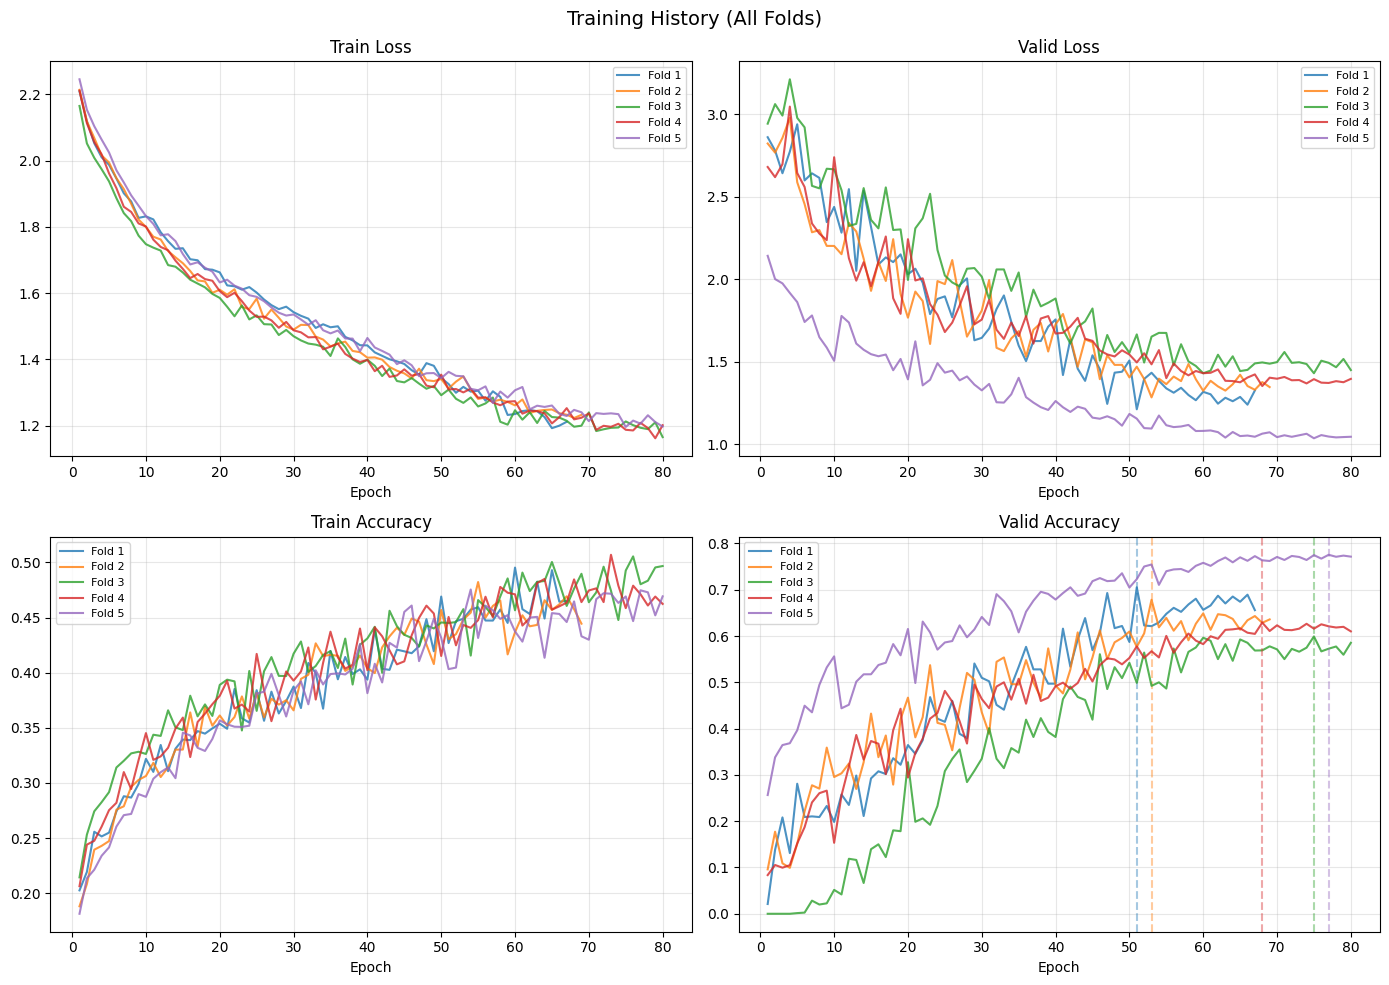

圖片已儲存：advanced_v3_training_history.png

各折訓練摘要：
  Fold  Best Epoch  Best Valid Acc
------------------------------------
     1          51         0.70531
     2          53         0.67842
     3          75         0.59920
     4          68         0.62900
     5          77         0.77554


In [56]:
# ── 視覺化訓練歷史 ──
import matplotlib.pyplot as plt

def plot_history(histories):
    """畫出每折的 train/valid loss 和 accuracy 曲線"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Training History (All Folds)", fontsize=14)

    colors = plt.cm.tab10(range(len(histories)))

    for hist, color in zip(histories, colors):
        fold_label = f"Fold {hist['fold']+1}"
        epochs     = range(1, len(hist["train_loss"]) + 1)

        axes[0, 0].plot(epochs, hist["train_loss"], color=color, label=fold_label, alpha=0.8)
        axes[0, 1].plot(epochs, hist["valid_loss"], color=color, label=fold_label, alpha=0.8)
        axes[1, 0].plot(epochs, hist["train_acc"],  color=color, label=fold_label, alpha=0.8)
        axes[1, 1].plot(epochs, hist["valid_acc"],  color=color, label=fold_label, alpha=0.8)

        # 標記 best epoch（垂直虛線）
        best_ep = hist["best_epoch"]
        if 0 < best_ep <= len(hist["valid_acc"]):
            axes[1, 1].axvline(x=best_ep, color=color, linestyle="--", alpha=0.4)

    titles = ["Train Loss", "Valid Loss", "Train Accuracy", "Valid Accuracy"]
    for ax, title in zip(axes.flat, titles):
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{_exp_name}_training_history.png", dpi=150)
    plt.show()
    print(f"圖片已儲存：{_exp_name}_training_history.png")

if all_histories:
    plot_history(all_histories)

# 各折摘要表
print("\n各折訓練摘要：")
print(f"  Fold  Best Epoch  Best Valid Acc")
print("-" * 36)
for hist in all_histories:
    print(f"  {hist['fold']+1:>4}  {hist['best_epoch']:>10}  {hist['best_acc']:>14.5f}")

# Testing with TTA（16 次）+ Ensemble

In [57]:
test_set = FoodDataset(f"{DATA_DIR}/test", tfm=test_tfm)
test_loader_normal = DataLoader(test_set, batch_size=batch_size,
                                shuffle=False, num_workers=2,
                                persistent_workers=True, pin_memory=True)

class TTADataset(Dataset):
    """每次 __getitem__ 都重新用 tta_tfm 隨機增強，確保 TTA 每次不同"""
    def __init__(self, base_dataset, tta_tfm):
        self.tta_tfm  = tta_tfm
        self.pil_imgs = []
        for f in base_dataset.files:
            self.pil_imgs.append(Image.open(f).convert("RGB"))

    def __len__(self):
        return len(self.pil_imgs)

    def __getitem__(self, idx):
        return self.tta_tfm(self.pil_imgs[idx]), -1

tta_dataset = TTADataset(test_set, tta_tfm)

print(f"測試集大小：{len(test_set)}")
print(f"TTA 次數：{tta_times}")
print(f"參與 Ensemble 的模型數：{n_folds} 折")
print(f"總預測次數（每張圖）：{n_folds} × ({tta_times}+1) = {n_folds*(tta_times+1)}")

測試集大小：3000
TTA 次數：16
參與 Ensemble 的模型數：5 折
總預測次數（每張圖）：5 × (16+1) = 85


In [58]:
all_logits = torch.zeros(len(test_set), 11)

for k in range(n_folds):
    ckpt_path = f"{_exp_name}_fold{k}.ckpt"
    if not os.path.exists(ckpt_path):
        print(f"找不到 {ckpt_path}，跳過")
        continue

    model_k = Classifier().to(device)
    model_k.load_state_dict(torch.load(ckpt_path))
    model_k.eval()
    print(f"\nFold {k+1} 模型載入完成")

    # 1. 一般預測（不做增強）
    print(f"  Fold {k+1} 一般預測...")
    with torch.no_grad():
        for i, (imgs, _) in enumerate(tqdm(test_loader_normal)):
            logits = model_k(imgs.to(device)).cpu()
            start  = i * batch_size
            end    = start + logits.size(0)
            all_logits[start:end] += logits

    # 2. TTA 預測（每次重新建 DataLoader 確保隨機增強不同）
    for t in range(tta_times):
        print(f"  Fold {k+1} TTA {t+1}/{tta_times}...")
        tta_loader_t = DataLoader(
            tta_dataset, batch_size=batch_size,
            shuffle=False, num_workers=0, pin_memory=True
        )
        with torch.no_grad():
            for i, (imgs, _) in enumerate(tqdm(tta_loader_t)):
                logits = model_k(imgs.to(device)).cpu()
                start  = i * batch_size
                end    = start + logits.size(0)
                all_logits[start:end] += logits

prediction = all_logits.argmax(dim=1).numpy().tolist()
print(f"\n預測完成！共 {len(prediction)} 筆")


Fold 1 模型載入完成
  Fold 1 一般預測...


  0%|          | 0/94 [00:00<?, ?it/s]

  Fold 1 TTA 1/16...


  0%|          | 0/94 [00:00<?, ?it/s]

  Fold 1 TTA 2/16...


...

  Fold 5 TTA 15/16...


  0%|          | 0/94 [00:00<?, ?it/s]

  Fold 5 TTA 16/16...


  0%|          | 0/94 [00:00<?, ?it/s]


預測完成！共 3000 筆


# Generate submission.csv

In [59]:
def pad4(i):
    return str(i).zfill(4)

df = pd.DataFrame()
df["Id"]       = [pad4(i) for i in range(len(test_set))]
df["Category"] = prediction
df.to_csv("submission.csv", index=False)
print("submission.csv 已儲存！")
print(df.head(10))

from IPython.display import FileLink
FileLink('submission.csv')

submission.csv 已儲存！
     Id  Category
0  0000         5
1  0001         1
2  0002         1
3  0003         3
4  0004         9
5  0005        10
6  0006         3
7  0007         3
8  0008         1
9  0009         3


/kaggle/working/submission.csv

# Q1. Augmentation Implementation（GradeScope 提交版）

In [ ]:
train_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomCrop(128, padding=16),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

# Q2. t-SNE 視覺化

**layer index：**
- mid layer = `model.cnn[:8]`（Block 1~2 後）
- top layer = `model.cnn[:19]`（全部 6 個 Block 後）

In [60]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

model_vis = Classifier().to(device)
model_vis.load_state_dict(torch.load(f"{_exp_name}_fold0.ckpt"))
model_vis.eval()

print("CNN sub-layers:")
for i, layer in enumerate(model_vis.cnn):
    print(f"  [{i}] {layer}")

CNN sub-layers:
  [0] Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [1] BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [2] ReLU()
  [3] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  [4] Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [5] BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [6] ReLU()
  [7] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  [8] Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [9] BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [10] ReLU()
  [11] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  [12] Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [13] BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [14] ReLU()
  [15] MaxPool2d(kernel_size=2, stride=2, pad

Extracting [Mid Layer (Block 1-2)]:   0%|          | 0/57 [00:00<?, ?it/s]

[Mid Layer (Block 1-2)] feature 維度：(3643, 131072)
[Mid Layer (Block 1-2)] 執行 t-SNE 中（可能需要數分鐘）...


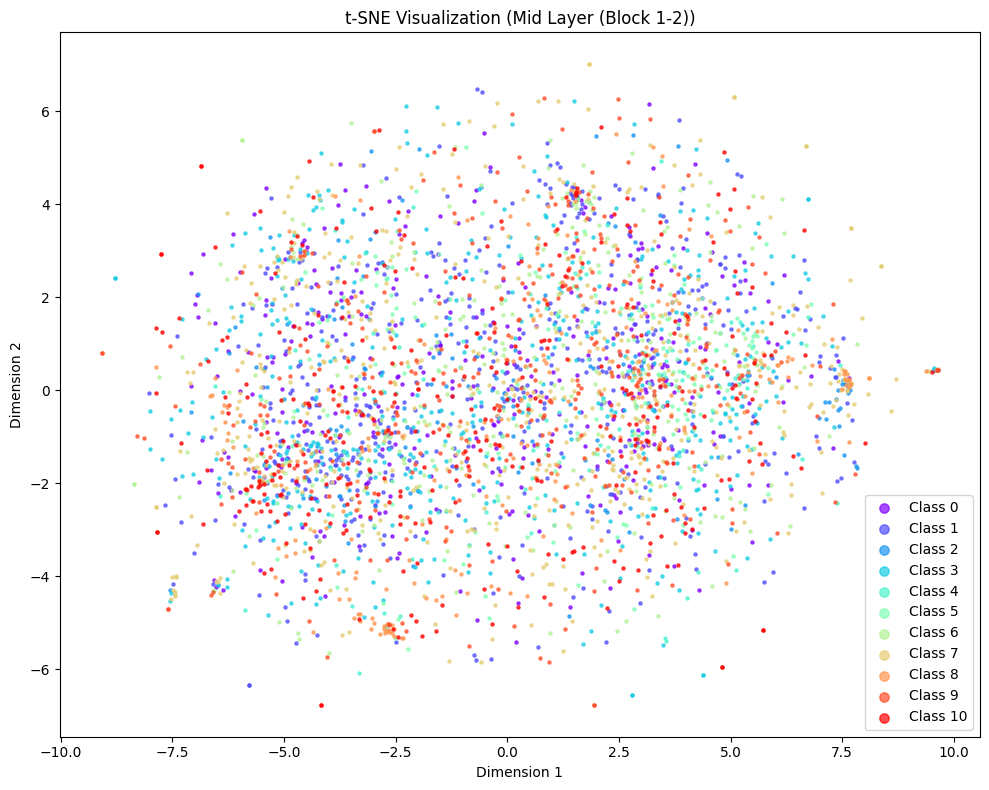

圖片已儲存：tsne_Mid_Layer_(Block_1-2).png


Extracting [Top Layer (Block 1-6)]:   0%|          | 0/57 [00:00<?, ?it/s]

[Top Layer (Block 1-6)] feature 維度：(3643, 32768)
[Top Layer (Block 1-6)] 執行 t-SNE 中（可能需要數分鐘）...


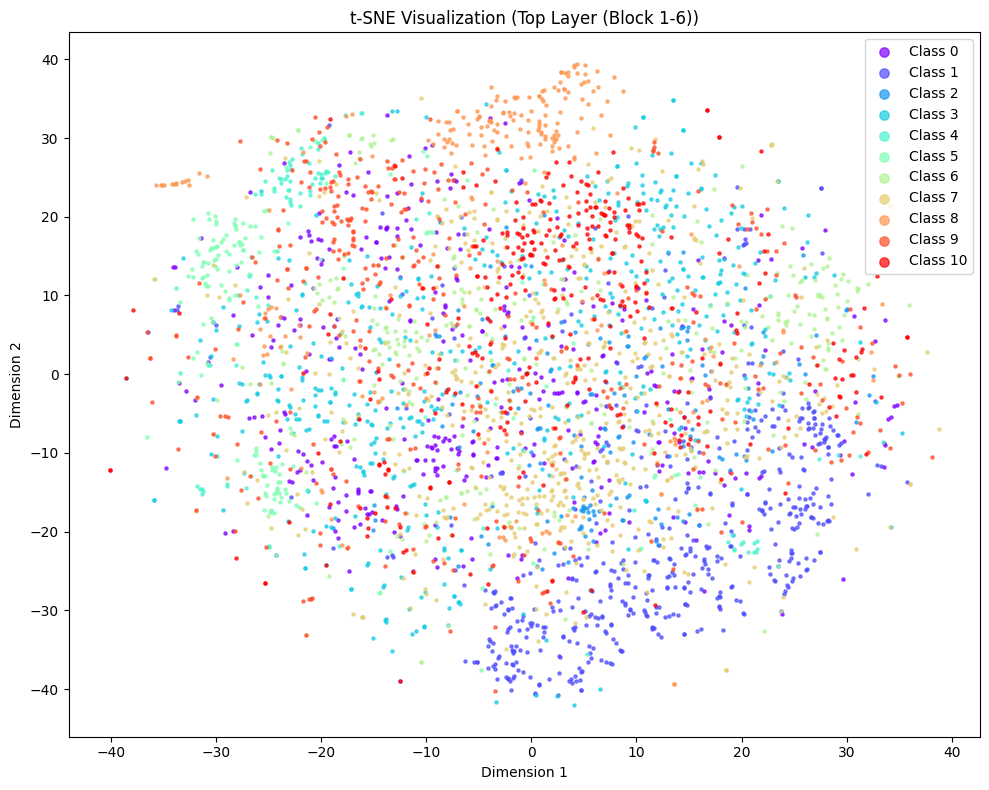

圖片已儲存：tsne_Top_Layer_(Block_1-6).png


In [62]:
vis_valid_set    = FoodDataset(f"{DATA_DIR}/valid", tfm=test_tfm)
vis_valid_loader = DataLoader(vis_valid_set, batch_size=64,
                               shuffle=False, num_workers=2,
                               persistent_workers=True, pin_memory=True)

def visualize_tsne(model, loader, layer_index, title, device):
    features_list, labels_list = [], []
    for imgs, lbls in tqdm(loader, desc=f"Extracting [{title}]"):
        with torch.no_grad():
            feat = model.cnn[:layer_index](imgs.to(device))
            feat = feat.view(feat.size(0), -1)
        features_list.extend(feat.cpu().numpy())
        labels_list.extend(lbls.numpy())

    features = np.array(features_list)
    labels   = np.array(labels_list)
    print(f"[{title}] feature 維度：{features.shape}")
    print(f"[{title}] 執行 t-SNE 中（可能需要數分鐘）...")

    features_2d = TSNE(n_components=2, init='pca',
                       random_state=42, perplexity=30).fit_transform(features)

    plt.figure(figsize=(10, 8))
    colors = cm.rainbow(np.linspace(0, 1, 11))
    for label_id in np.unique(labels):
        mask = (labels == label_id)
        plt.scatter(features_2d[mask, 0], features_2d[mask, 1],
                    label=f"Class {label_id}", color=colors[label_id],
                    s=5, alpha=0.7)
    plt.legend(markerscale=3, loc='best')
    plt.title(f"t-SNE Visualization ({title})")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.tight_layout()
    fname = f"tsne_{title.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"圖片已儲存：{fname}")

# mid layer（Block 1~2 後，index=8）
visualize_tsne(model_vis, vis_valid_loader, layer_index=8,
               title="Mid Layer (Block 1-2)", device=device)

# top layer（全部 6 個 Block 後，index=19）
visualize_tsne(model_vis, vis_valid_loader, layer_index=19,
               title="Top Layer (Block 1-6)", device=device)